<a href="https://colab.research.google.com/github/charlien12/ML-Projects/blob/main/PowerPlant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv('sample_data/powerplant_data.csv')

In [ ]:
X=df.drop('PE',axis=1)
Y=df['PE']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
import torch.nn as nn
import torch

In [ ]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
Y_train_tensor=torch.tensor(Y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
Y_test_tensor=torch.tensor(Y_test.values,dtype=torch.float32).view(-1,1)

In [ ]:
from torch.utils.data import TensorDataset,DataLoader

In [ ]:
train_dataset=TensorDataset(X_train_tensor,Y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,Y_test_tensor)

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

# Evaluate Deep Learning

In [ ]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
    self.model=nn.Sequential(
      nn.Linear(X_train.shape[1],6),
      nn.ReLU(),
      nn.Linear(6,6),
      nn.ReLU(),
      nn.Linear(6,1))
  def forward(self,x):
    return self.model(x)

In [ ]:
import torch.optim as optim
model=ANN()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

# Train the Model

In [15]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 188302.98248697916 & val loss = 168813.671875
epoch 2/100 ==> train loss = 138453.5773111979 & val loss = 105271.15625
epoch 3/100 ==> train loss = 74702.11666666667 & val loss = 49825.08203125
epoch 4/100 ==> train loss = 35811.757071940105 & val loss = 26505.43359375
epoch 5/100 ==> train loss = 21884.17539469401 & val loss = 18352.73828125
epoch 6/100 ==> train loss = 16222.756103515625 & val loss = 14142.029296875
epoch 7/100 ==> train loss = 12485.846305338542 & val loss = 10722.9912109375
epoch 8/100 ==> train loss = 9228.60273030599 & val loss = 7690.12353515625
epoch 9/100 ==> train loss = 6432.196785481771 & val loss = 5208.125
epoch 10/100 ==> train loss = 4279.454723103841 & val loss = 3434.357666015625
epoch 11/100 ==> train loss = 2802.8462814331056 & val loss = 2280.50439453125
epoch 12/100 ==> train loss = 1884.7232208251953 & val loss = 1583.39013671875
epoch 13/100 ==> train loss = 1317.8392728169758 & val loss = 1142.314208984375
epoch 14/

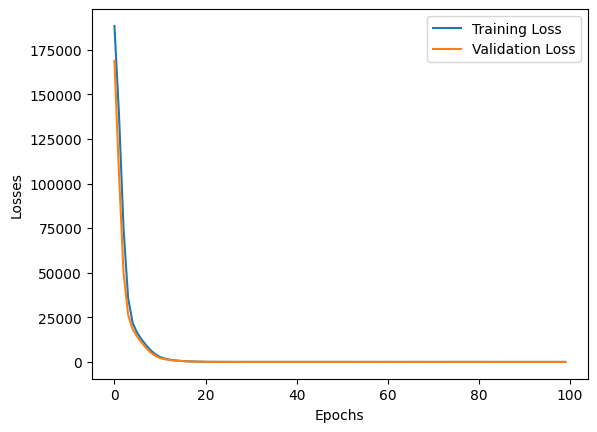

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [17]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [20]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, Y_train_tensor)
    test_mse_loss = criterion(test_preds, Y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.29190444946289
Testing MSE: 19.58078384399414


In [22]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(Y_test, test_preds))

r^2 score = 0.9315702078573241


In [24]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(Y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.525330,433.27
1,436.970856,438.16
2,460.636200,458.42
3,475.430786,480.82
4,435.219666,441.41
...,...,...
1909,451.214111,456.70
1910,431.779419,438.04
1911,467.524445,467.80
1912,431.203735,437.14
